In [8]:

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"
os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

from pathlib import Path

DATASET_ROOT_EXPLICIT = ""
BASE_MODEL_EXPLICIT = ""


ALLOW_BASE_MODEL_DOWNLOAD = True
BASE_MODEL_REPO = "stable-diffusion-v1-5/stable-diffusion-v1-5"

EXPECTED_IMAGES = 143
EXPECTED_TRAIN_IMAGES = 142
TRIGGER_TOKEN = "cerwall"

RESOLUTION = 512
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 1
NUM_REPEATS = 1
MAX_TRAIN_EPOCHS = 15

NETWORK_DIM = 32
NETWORK_ALPHA = 16
LEARNING_RATE = 1e-4
LR_SCHEDULER = "cosine"
MIN_SNR_GAMMA = 5.0

SAVE_EVERY_N_EPOCHS = 2
SEED = 42
LORA_TEST_WEIGHT = 0.85
RUN_SMOKE_TEST = True
RUN_CHECKPOINT_EVOLUTION = True

WORK_ROOT = Path("/kaggle/working/ceramic_wall_lora_project")
SD_SCRIPTS_DIR = Path("/kaggle/working/sd-scripts")
TRAIN_DIR = WORK_ROOT / "train_data"
SMOKE_DIR = WORK_ROOT / "smoke_data"
OUTPUT_DIR = WORK_ROOT / "output"
LOG_DIR = WORK_ROOT / "logs"
FULL_LOG_DIR = LOG_DIR / "full"
SMOKE_LOG_DIR = LOG_DIR / "smoke"
PREVIEW_DIR = WORK_ROOT / "previews"
EVAL_DIR = PREVIEW_DIR / "evaluation"

DATASET_CONFIG = WORK_ROOT / "dataset_config.toml"
SMOKE_CONFIG = WORK_ROOT / "smoke_dataset_config.toml"
MANIFEST_CSV = WORK_ROOT / "manifest.csv"

for p in [
    WORK_ROOT, TRAIN_DIR, SMOKE_DIR, OUTPUT_DIR, FULL_LOG_DIR,
    SMOKE_LOG_DIR, PREVIEW_DIR, EVAL_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

print("Work root:", WORK_ROOT)
print("Trigger token:", TRIGGER_TOKEN)


Work root: /kaggle/working/ceramic_wall_lora_project
Trigger token: cerwall


In [2]:

import sys
import platform
import subprocess
import torch

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)

subprocess.run(["nvidia-smi"], check=False)

assert torch.cuda.is_available(), (
    "فعّلي GPU من Kaggle > Settings > Accelerator."
)

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
major, minor = torch.cuda.get_device_capability(0)
current_arch = f"sm_{major}{minor}"
compiled_arches = torch.cuda.get_arch_list()

print("GPU:", gpu_name)
print(f"VRAM: {vram_gb:.1f} GB")
print("Compute capability:", current_arch)
print("Torch compiled architectures:", compiled_arches)

assert current_arch in compiled_arches, (
    f"نسخة PyTorch الحالية لا تحتوي دعم {current_arch}. "
    f"GPU الحالية: {gpu_name}. اختاري T4 من Kaggle أو استخدمي Runtime مختلفًا."
)

x = torch.randn(32, 32, device="cuda")
y = x @ x
torch.cuda.synchronize()
del x, y
torch.cuda.empty_cache()

print("CUDA execution test passed.")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA runtime: 12.8
Sun Aug  2 15:13:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Defau

In [3]:

import shutil
import subprocess
import sys
from pathlib import Path

SD_SCRIPTS_TAG = "v0.10.6"
INSTALL_MARKER = Path("/kaggle/working/.sd_scripts_v0_10_6_installed")



REPO_TAG_FILE = SD_SCRIPTS_DIR / ".kaggle_pinned_tag"
repo_ready = (
    (SD_SCRIPTS_DIR / "train_network.py").is_file()
    and (SD_SCRIPTS_DIR / "requirements.txt").is_file()
    and REPO_TAG_FILE.is_file()
    and REPO_TAG_FILE.read_text(encoding="utf-8").strip() == SD_SCRIPTS_TAG
)

if not repo_ready:
    if SD_SCRIPTS_DIR.exists():
        shutil.rmtree(SD_SCRIPTS_DIR)

    print("Cloning sd-scripts...")
    clone = subprocess.run(
        [
            "git", "clone", "--depth", "1", "--branch", SD_SCRIPTS_TAG,
            "https://github.com/kohya-ss/sd-scripts.git",
            str(SD_SCRIPTS_DIR),
        ],
        text=True,
        capture_output=True,
    )
    if clone.returncode != 0:
        print(clone.stdout)
        print(clone.stderr)
        raise RuntimeError(
            "فشل تنزيل sd-scripts. فعّلي Internet من إعدادات Kaggle ثم أعيدي تشغيل الخلية."
        )
    REPO_TAG_FILE.write_text(SD_SCRIPTS_TAG, encoding="utf-8")

if not INSTALL_MARKER.exists():
    print("Installing official sd-scripts requirements in Kaggle Python...")

    install = subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet",
            "--no-cache-dir",
            "--upgrade-strategy", "only-if-needed",
            "-r", str(SD_SCRIPTS_DIR / "requirements.txt"),
        ],
        cwd=str(SD_SCRIPTS_DIR),
        text=True,
        capture_output=True,
    )

    if install.returncode != 0:
        print(install.stdout)
        print(install.stderr)
        raise RuntimeError("فشل تثبيت متطلبات sd-scripts.")

    peft_install = subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--no-cache-dir",
            "peft==0.14.0",
        ],
        text=True,
        capture_output=True,
    )
    if peft_install.returncode != 0:
        print(peft_install.stdout)
        print(peft_install.stderr)
        raise RuntimeError("فشل تثبيت PEFT المستخدم لاختبار LoRA.")

else:
    print("Dependencies already installed in this Kaggle session.")

check_code = """
import torch, accelerate, transformers, diffusers, safetensors, bitsandbytes
print('torch        :', torch.__version__)
print('accelerate   :', accelerate.__version__)
print('transformers :', transformers.__version__)
print('diffusers    :', diffusers.__version__)
print('safetensors  :', safetensors.__version__)
print('bitsandbytes :', bitsandbytes.__version__)
"""
version_check = subprocess.run(
    [sys.executable, "-c", check_code],
    text=True,
    capture_output=True,
)
print(version_check.stdout)
if version_check.returncode != 0:
    print(version_check.stderr)
    INSTALL_MARKER.unlink(missing_ok=True)
    raise RuntimeError("فشل فحص مكتبات التدريب بعد التثبيت.")

INSTALL_MARKER.touch()
print("sd-scripts ready:", SD_SCRIPTS_DIR)


Cloning sd-scripts...
Installing official sd-scripts requirements in Kaggle Python...
torch        : 2.10.0+cu128
accelerate   : 1.6.0
transformers : 4.54.1
diffusers    : 0.32.1
safetensors  : 0.4.5
bitsandbytes : 0.50.0

sd-scripts ready: /kaggle/working/sd-scripts


In [5]:

import gc
import json
import math
import random
import re
import shutil
from pathlib import Path
from typing import Union

import numpy as np
import pandas as pd
from PIL import Image

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

def find_dataset_root() -> Path:
    """Find the uploaded ceramic dataset exactly as it exists on Kaggle."""
    if DATASET_ROOT_EXPLICIT:
        explicit = Path(DATASET_ROOT_EXPLICIT)
        if explicit.is_dir() and (explicit / "10_cerwall").is_dir():
            return explicit
        print(f"تنبيه: المسار الصريح غير صالح، سأبحث تلقائياً: {explicit}")

    candidates = []
    for folder in Path("/kaggle/input").rglob("10_cerwall"):
        if not folder.is_dir():
            continue
        root = folder.parent
        has_metadata = (
            (root / "metadata_clean.json").is_file()
            or (root / "keep_core_ceramic_lora_metadata.jsonl").is_file()
        )
        if has_metadata:
            candidates.append(root)

    candidates = sorted(set(candidates))
    assert candidates, (
        "لم أجد مجلد 10_cerwall مع ملف JSON/JSONL داخل /kaggle/input."
    )

    if len(candidates) > 1:
        print("Dataset candidates:")
        for candidate in candidates:
            print(" -", candidate)
        raise RuntimeError(
            "وجدت أكثر من داتاست مرشحة. حددي DATASET_ROOT_EXPLICIT في الخلية الأولى."
        )

    return candidates[0]

def find_metadata_path(dataset_root: Path) -> Path:
    candidates = [
        dataset_root / "metadata_clean.json",
        dataset_root / "keep_core_ceramic_lora_metadata.jsonl",
    ]
    for path in candidates:
        if path.is_file():
            return path
    raise FileNotFoundError(
        f"لم أجد metadata_clean.json أو keep_core_ceramic_lora_metadata.jsonl داخل {dataset_root}"
    )

def find_base_model() -> Union[Path, str]:
    if BASE_MODEL_EXPLICIT:
        explicit = Path(BASE_MODEL_EXPLICIT)
        if explicit.exists():
            return explicit
        if "/" in BASE_MODEL_EXPLICIT:
            return BASE_MODEL_EXPLICIT
        raise FileNotFoundError(f"Base model غير موجود: {BASE_MODEL_EXPLICIT}")

    diffusers_dirs = []
    for model_index in Path("/kaggle/input").rglob("model_index.json"):
        parent = model_index.parent
        try:
            info = json.loads(model_index.read_text(encoding="utf-8"))
        except Exception:
            continue

        pipeline_class = str(info.get("_class_name", ""))
        is_sd_pipeline = pipeline_class == "StableDiffusionPipeline"
        has_required_parts = (
            (parent / "unet").is_dir()
            and (parent / "vae").is_dir()
            and (parent / "tokenizer").is_dir()
            and (parent / "text_encoder").is_dir()
        )
        if is_sd_pipeline and has_required_parts:
            diffusers_dirs.append(parent)

    diffusers_dirs = sorted(set(diffusers_dirs))
    if len(diffusers_dirs) == 1:
        return diffusers_dirs[0]
    if len(diffusers_dirs) > 1:
        preferred = [
            p for p in diffusers_dirs
            if any(token in str(p).lower() for token in [
                "stable-diffusion-v1-5", "sd15", "sd-v1-5"
            ])
        ]
        if len(preferred) == 1:
            return preferred[0]
        print("وجدت أكثر من Stable Diffusion Pipeline:")
        for p in diffusers_dirs:
            print(" -", p)
        raise RuntimeError(
            "حددي BASE_MODEL_EXPLICIT حتى لا يتم اختيار Base Model خاطئ."
        )

    checkpoints = []
    for path in Path("/kaggle/input").rglob("*.safetensors"):
        name = path.name.lower()
        is_sd15 = (
            "v1-5-pruned" in name
            or "sd15" in name
            or "sd-v1-5" in name
        )
        if is_sd15 and "lora" not in name:
            checkpoints.append(path)

    checkpoints = sorted(set(checkpoints))
    if len(checkpoints) == 1:
        return checkpoints[0]
    if len(checkpoints) > 1:
        ema_only = [p for p in checkpoints if "emaonly" in p.name.lower()]
        if len(ema_only) == 1:
            return ema_only[0]
        print("وجدت أكثر من SD 1.5 checkpoint:")
        for p in checkpoints:
            print(" -", p)
        raise RuntimeError(
            "حددي BASE_MODEL_EXPLICIT حتى لا يتم اختيار Checkpoint خاطئ."
        )

    if ALLOW_BASE_MODEL_DOWNLOAD:
        return BASE_MODEL_REPO

    raise FileNotFoundError(
        "لم أجد SD 1.5 محليًا. ارفعيه كـKaggle Dataset أو فعّلي التنزيل."
    )

DATASET_ROOT = find_dataset_root()
SOURCE_DIR = DATASET_ROOT / "10_cerwall"
METADATA_PATH = find_metadata_path(DATASET_ROOT)
BASE_MODEL = find_base_model()

print("DATASET_ROOT:", DATASET_ROOT)
print("SOURCE_DIR  :", SOURCE_DIR)
print("METADATA    :", METADATA_PATH)
print("BASE_MODEL  :", BASE_MODEL)

assert SOURCE_DIR.is_dir()
assert METADATA_PATH.is_file()

if isinstance(BASE_MODEL, Path) and BASE_MODEL.is_file():
    print(f"Base checkpoint size: {BASE_MODEL.stat().st_size / 1024**3:.2f} GB")
    assert BASE_MODEL.stat().st_size > 3 * 1024**3, (
        "ملف SD 1.5 المحلي يبدو ناقصًا."
    )


DATASET_ROOT: /kaggle/input/datasets/ayasahlol/ceramic/ceramic_walls_reviewed
SOURCE_DIR  : /kaggle/input/datasets/ayasahlol/ceramic/ceramic_walls_reviewed/10_cerwall
METADATA    : /kaggle/input/datasets/ayasahlol/ceramic/ceramic_walls_reviewed/keep_core_ceramic_lora_metadata.jsonl
BASE_MODEL  : stable-diffusion-v1-5/stable-diffusion-v1-5


In [9]:
def load_metadata_records(metadata_path: Path):
    if metadata_path.suffix.lower() == ".jsonl":
        records = []
        with metadata_path.open("r", encoding="utf-8-sig") as handle:
            for line_number, line in enumerate(handle, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError as exc:
                    raise ValueError(
                        f"JSONL غير صالح في السطر {line_number}: {exc}"
                    ) from exc
        return records

    raw_metadata = json.loads(
        metadata_path.read_text(encoding="utf-8-sig")
    )
    if isinstance(raw_metadata, dict) and isinstance(raw_metadata.get("images"), list):
        return raw_metadata["images"]
    if isinstance(raw_metadata, list):
        return raw_metadata
    raise ValueError(f"بنية ملف metadata غير مدعومة: {metadata_path.name}")


# ------------------------------------------------------------
# 1) Read the complete metadata file without filtering it first.
# ------------------------------------------------------------
records = load_metadata_records(METADATA_PATH)

source_images = sorted(
    p for p in SOURCE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)
source_txt = sorted(SOURCE_DIR.glob("*.txt"))

assert len(records) == EXPECTED_IMAGES, (
    f"عدد سجلات metadata الخام يجب أن يكون {EXPECTED_IMAGES}، الموجود {len(records)}."
)
assert len(source_images) == EXPECTED_IMAGES, (
    f"عدد الصور يجب أن يكون {EXPECTED_IMAGES}، الموجود {len(source_images)}."
)
assert len(source_txt) == EXPECTED_IMAGES, (
    f"عدد ملفات TXT يجب أن يكون {EXPECTED_IMAGES}، الموجود {len(source_txt)}."
)


# ------------------------------------------------------------
# 2) Build strict filename maps and verify one-to-one matching.
# ------------------------------------------------------------
images_by_name = {p.name.lower(): p for p in source_images}
txt_by_stem = {p.stem.lower(): p for p in source_txt}

metadata_by_name = {}
duplicate_metadata = []

for item in records:
    file_name = str(
        item.get("file_name")
        or item.get("relative_path")
        or ""
    ).strip()

    normalized_name = Path(file_name).name.lower()

    if not normalized_name:
        raise ValueError("وجدت سجل metadata بلا file_name أو relative_path.")

    if normalized_name in metadata_by_name:
        duplicate_metadata.append(normalized_name)

    metadata_by_name[normalized_name] = item

assert not duplicate_metadata, (
    f"توجد أسماء صور مكررة داخل metadata: {duplicate_metadata[:20]}"
)

missing_metadata = sorted(set(images_by_name) - set(metadata_by_name))
metadata_without_image = sorted(set(metadata_by_name) - set(images_by_name))

image_stems = {p.stem.lower() for p in source_images}
txt_stems = set(txt_by_stem)

images_without_txt = sorted(image_stems - txt_stems)
txt_without_images = sorted(txt_stems - image_stems)

assert not missing_metadata, (
    f"صور بلا سجل metadata: {missing_metadata[:20]}"
)
assert not metadata_without_image, (
    f"سجلات metadata بلا صورة: {metadata_without_image[:20]}"
)
assert not images_without_txt, (
    f"صور بلا ملف TXT: {images_without_txt[:20]}"
)
assert not txt_without_images, (
    f"ملفات TXT بلا صورة: {txt_without_images[:20]}"
)


# ------------------------------------------------------------
# 3) Select only training-safe records.
#
# Current dataset:
# - ceramic_wall_0031.jpg -> use_with_specific_caption -> accepted.
# - ceramic_wall_0192.jpg -> use_after_watermark_crop + watermark -> excluded.
# ------------------------------------------------------------
ALLOWED_TRAINING_DECISIONS = {
    "use",
    "use_with_specific_caption",
}

rows = []
excluded_rows = []
errors = []
caption_mismatches = []

for image_path in source_images:
    item = metadata_by_name[image_path.name.lower()]
    txt_path = txt_by_stem[image_path.stem.lower()]

    file_name = image_path.name
    decision = str(item.get("training_decision", "use")).strip()
    keep_status = str(item.get("keep_status", "keep_core")).strip()
    training_ready = item.get("training_ready", True)
    has_watermark = item.get("watermark", False) is True
    recommended_weight = item.get("recommended_training_weight", 1.0)

    exclusion_reasons = []

    if training_ready is False:
        exclusion_reasons.append("training_ready=False")

    if keep_status != "keep_core":
        exclusion_reasons.append(f"keep_status={keep_status}")

    if decision not in ALLOWED_TRAINING_DECISIONS:
        exclusion_reasons.append(f"training_decision={decision}")

    if has_watermark:
        exclusion_reasons.append("watermark=True")

    try:
        if recommended_weight is not None and float(recommended_weight) <= 0:
            exclusion_reasons.append(
                f"recommended_training_weight={recommended_weight}"
            )
    except (TypeError, ValueError):
        errors.append((file_name, "invalid recommended_training_weight"))

    if exclusion_reasons:
        excluded_rows.append({
            "file_name": file_name,
            "reasons": " | ".join(exclusion_reasons),
        })
        continue

    caption_json = " ".join(str(item.get("text", "")).split())

    # Kohya trains from the .txt sidecar, so TXT is authoritative.
    caption_txt = " ".join(
        txt_path.read_text(encoding="utf-8-sig").split()
    )

    if not caption_txt:
        errors.append((file_name, "empty caption"))

    if caption_json and caption_txt != caption_json:
        caption_mismatches.append(file_name)

    if not caption_txt.lower().startswith(TRIGGER_TOKEN.lower()):
        errors.append((file_name, "caption does not start with trigger"))

    if re.search(r"\bfloor\b", caption_txt.lower()):
        errors.append((file_name, "caption contains floor"))

    if str(item.get("trigger_token", TRIGGER_TOKEN)).lower() != TRIGGER_TOKEN.lower():
        errors.append((file_name, "metadata trigger mismatch"))

    try:
        with Image.open(image_path) as image:
            width, height = image.size
            image.load()
            image.convert("RGB")
    except Exception as exc:
        errors.append((file_name, f"invalid image: {exc!r}"))
        continue

    rows.append({
        "file_name": image_path.name,
        "image_path": str(image_path),
        "txt_path": str(txt_path),
        "caption": caption_txt,
        "metadata_caption": caption_json,
        "width": width,
        "height": height,
        "min_side": min(width, height),
        "room_type": item.get("room_type", ""),
        "application_area": item.get("application_area", ""),
        "look_type": item.get("look_type", ""),
        "tile_shape": item.get("tile_shape", ""),
        "tile_size_class": item.get("tile_size_class", ""),
        "layout_pattern": item.get("layout_pattern", ""),
        "finish": item.get("finish", ""),
        "primary_color": item.get("primary_color", ""),
        "annotation_confidence": item.get("annotation_confidence", ""),
        "training_decision": decision,
        "recommended_training_weight": recommended_weight,
    })


# ------------------------------------------------------------
# 4) Final integrity rules.
# ------------------------------------------------------------
assert not errors, f"وجدت أخطاء حقيقية في الداتاست: {errors[:20]}"

manifest = pd.DataFrame(rows)
excluded_manifest = pd.DataFrame(excluded_rows)

assert len(manifest) == EXPECTED_TRAIN_IMAGES, (
    f"عدد صور التدريب النظيفة يجب أن يكون {EXPECTED_TRAIN_IMAGES}، "
    f"الموجود {len(manifest)}."
)

assert len(manifest) + len(excluded_manifest) == EXPECTED_IMAGES

assert manifest["caption"].nunique() > EXPECTED_TRAIN_IMAGES * 0.5

assert manifest["min_side"].min() >= RESOLUTION, (
    "توجد صورة أصغر من دقة التدريب 512."
)


# ------------------------------------------------------------
# 5) Copy only approved image/TXT pairs into Kaggle working space.
# ------------------------------------------------------------
if TRAIN_DIR.exists():
    shutil.rmtree(TRAIN_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

for row in manifest.itertuples(index=False):
    shutil.copy2(row.image_path, TRAIN_DIR / Path(row.image_path).name)
    shutil.copy2(row.txt_path, TRAIN_DIR / Path(row.txt_path).name)

if SMOKE_DIR.exists():
    shutil.rmtree(SMOKE_DIR)
SMOKE_DIR.mkdir(parents=True, exist_ok=True)

for row in manifest.head(4).itertuples(index=False):
    shutil.copy2(row.image_path, SMOKE_DIR / Path(row.image_path).name)
    shutil.copy2(row.txt_path, SMOKE_DIR / Path(row.txt_path).name)

manifest.to_csv(MANIFEST_CSV, index=False)

EXCLUDED_CSV = WORK_ROOT / "excluded_images.csv"
excluded_manifest.to_csv(EXCLUDED_CSV, index=False)


# ------------------------------------------------------------
# 6) Report.
# ------------------------------------------------------------
summary = pd.DataFrame([
    {"Field": "Metadata file", "Value": METADATA_PATH.name},
    {"Field": "Metadata records", "Value": len(records)},
    {"Field": "Source images", "Value": len(source_images)},
    {"Field": "Source TXT captions", "Value": len(source_txt)},
    {"Field": "Training images", "Value": len(manifest)},
    {"Field": "Excluded images", "Value": len(excluded_manifest)},
    {"Field": "Unique captions", "Value": manifest["caption"].nunique()},
    {"Field": "TXT/JSON text differences", "Value": len(caption_mismatches)},
    {"Field": "Minimum image side", "Value": int(manifest["min_side"].min())},
    {"Field": "Median image side", "Value": int(manifest["min_side"].median())},
    {"Field": "Resolution", "Value": RESOLUTION},
    {"Field": "Trigger token", "Value": TRIGGER_TOKEN},
])

display(summary)

if not excluded_manifest.empty:
    print("\nExcluded images:")
    display(excluded_manifest)

if caption_mismatches:
    print(
        f"\nتنبيه فقط: نص JSONL مختلف عن TXT في {len(caption_mismatches)} ملف. "
        "هذا ليس خطأ؛ التدريب سيستخدم ملفات TXT الموجودة بجانب الصور."
    )
    print("أول أمثلة:", caption_mismatches[:5])

print("\nTraining copy:", TRAIN_DIR)
print("Manifest:", MANIFEST_CSV)
print("Excluded list:", EXCLUDED_CSV)
print("Dataset integrity check passed.")


,Field,Value
0,Metadata file,keep_core_ceramic_lora_metadata.jsonl
1,Metadata records,143
2,Source images,143
3,Source TXT captions,143
4,Training images,142
5,Excluded images,1
6,Unique captions,130
7,TXT/JSON text differences,142
8,Minimum image side,512
9,Median image side,736



Excluded images:


,file_name,reasons
0,ceramic_wall_0192.jpg,training_decision=use_after_watermark_crop | w...



تنبيه فقط: نص JSONL مختلف عن TXT في 142 ملف. هذا ليس خطأ؛ التدريب سيستخدم ملفات TXT الموجودة بجانب الصور.
أول أمثلة: ['ceramic_wall_0001.jpg', 'ceramic_wall_0002.jpg', 'ceramic_wall_0003.jpg', 'ceramic_wall_0004.jpg', 'ceramic_wall_0005.jpg']

Training copy: /kaggle/working/ceramic_wall_lora_project/train_data
Manifest: /kaggle/working/ceramic_wall_lora_project/manifest.csv
Excluded list: /kaggle/working/ceramic_wall_lora_project/excluded_images.csv
Dataset integrity check passed.


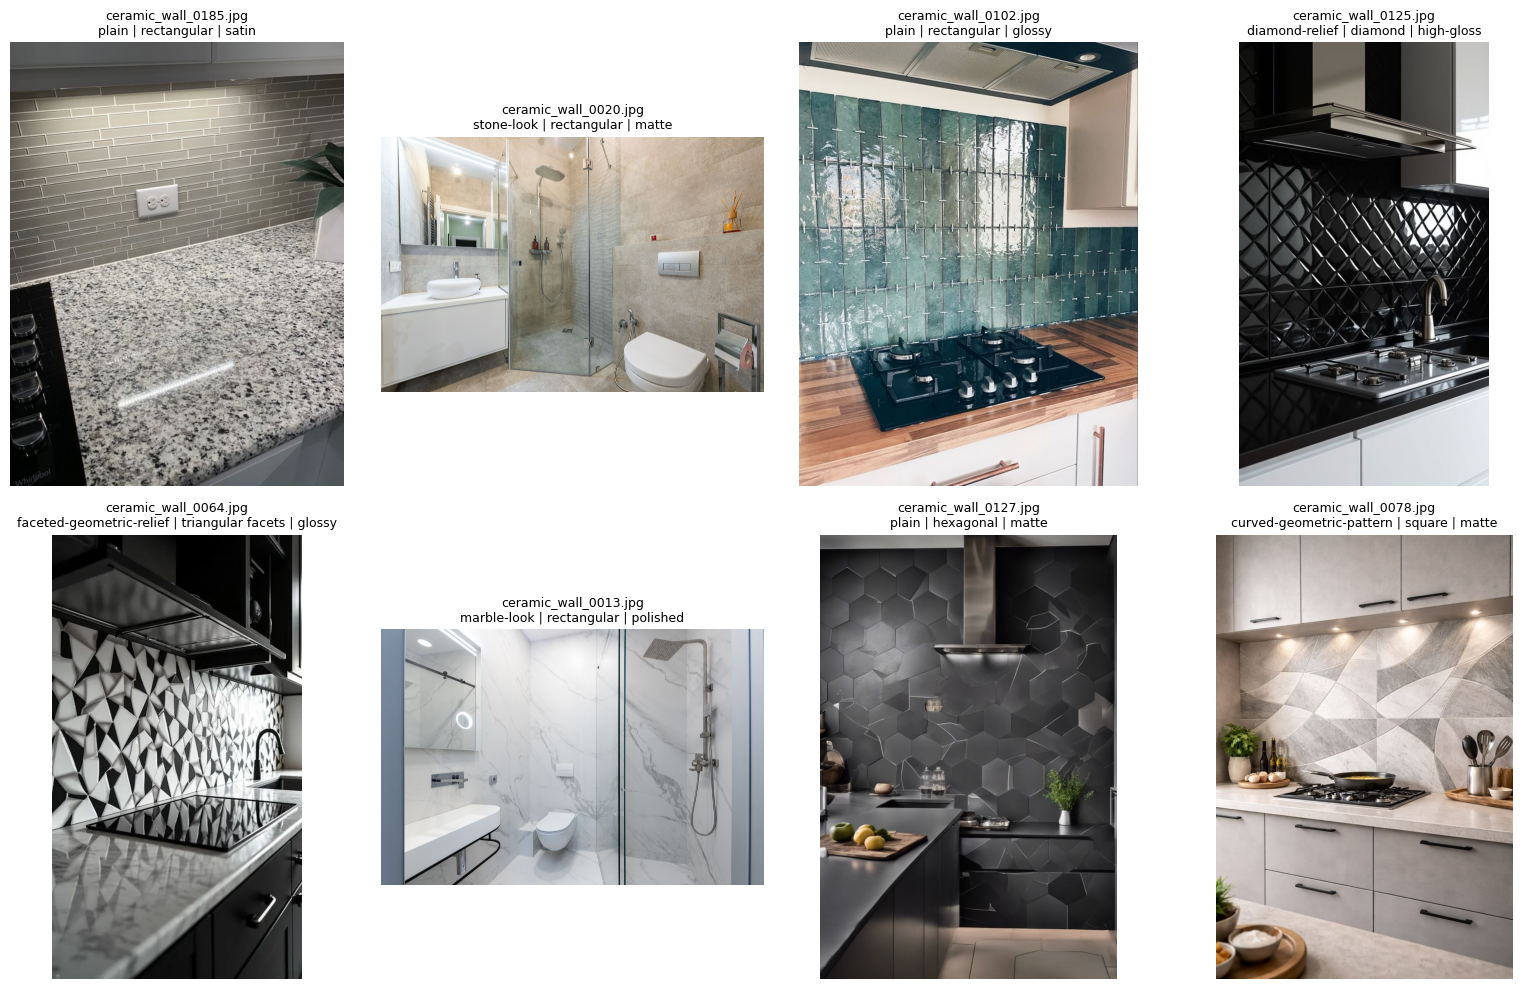

,file_name,application_area,look_type,tile_shape,tile_size_class,layout_pattern,finish,primary_color,caption
0,ceramic_wall_0185.jpg,backsplash,plain,rectangular,small,running-bond,satin,gray,"cerwall, photorealistic kitchen backsplash, sm..."
1,ceramic_wall_0020.jpg,bathroom wall,stone-look,rectangular,large-format,straight-grid,matte,beige,"cerwall, photorealistic bathroom wall, large-f..."
2,ceramic_wall_0102.jpg,backsplash,plain,rectangular,medium,vertical-running-bond,glossy,teal,"cerwall, photorealistic kitchen backsplash, me..."
3,ceramic_wall_0125.jpg,backsplash,diamond-relief,diamond,medium,diagonal-grid,high-gloss,black,"cerwall, photorealistic kitchen backsplash, me..."
4,ceramic_wall_0064.jpg,backsplash,faceted-geometric-relief,triangular facets,medium,tessellated-geometric,glossy,black and white,"cerwall, photorealistic kitchen backsplash, me..."
5,ceramic_wall_0013.jpg,bathroom wall,marble-look,rectangular,large-format,straight-grid,polished,white,"cerwall, photorealistic bathroom wall, large-f..."
6,ceramic_wall_0127.jpg,backsplash,plain,hexagonal,medium,honeycomb,matte,charcoal,"cerwall, photorealistic kitchen backsplash, me..."
7,ceramic_wall_0078.jpg,backsplash,curved-geometric-pattern,square,large-format,straight-grid,matte,gray,"cerwall, photorealistic kitchen backsplash, la..."


Saved: /kaggle/working/ceramic_wall_lora_project/previews/dataset_samples.png


In [10]:
import matplotlib.pyplot as plt

sample_rows = manifest.sample(
    n=min(8, len(manifest)),
    random_state=SEED,
).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for ax, row in zip(axes, sample_rows.itertuples(index=False)):
    image = Image.open(row.image_path).convert("RGB")
    ax.imshow(image)
    ax.set_title(
        f"{row.file_name}\n{row.look_type} | {row.tile_shape} | {row.finish}",
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()
dataset_preview_path = PREVIEW_DIR / "dataset_samples.png"
plt.savefig(dataset_preview_path, dpi=160, bbox_inches="tight")
plt.show()

display(
    sample_rows[[
        "file_name", "application_area", "look_type", "tile_shape",
        "tile_size_class", "layout_pattern", "finish", "primary_color", "caption"
    ]]
)
print("Saved:", dataset_preview_path)


In [11]:

dataset_toml = f"""
[general]
caption_extension = ".txt"
shuffle_caption = false
keep_tokens = 1

[[datasets]]
resolution = {RESOLUTION}
batch_size = {BATCH_SIZE}
enable_bucket = true
bucket_no_upscale = true
bucket_reso_steps = 64
min_bucket_reso = 256
max_bucket_reso = 1024

  [[datasets.subsets]]
  image_dir = "{TRAIN_DIR}"
  num_repeats = {NUM_REPEATS}
""".strip() + "\n"

smoke_toml = f"""
[general]
caption_extension = ".txt"
shuffle_caption = false
keep_tokens = 1

[[datasets]]
resolution = {RESOLUTION}
batch_size = 1
enable_bucket = true
bucket_no_upscale = true
bucket_reso_steps = 64
min_bucket_reso = 256
max_bucket_reso = 1024

  [[datasets.subsets]]
  image_dir = "{SMOKE_DIR}"
  num_repeats = 1
""".strip() + "\n"

DATASET_CONFIG.write_text(dataset_toml, encoding="utf-8")
SMOKE_CONFIG.write_text(smoke_toml, encoding="utf-8")

steps_per_epoch = math.ceil(
    len(manifest) * NUM_REPEATS
    / (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
)
estimated_steps = steps_per_epoch * MAX_TRAIN_EPOCHS

training_plan = pd.DataFrame([
    {"Parameter": "Images", "Value": len(manifest)},
    {"Parameter": "Repeats", "Value": NUM_REPEATS},
    {"Parameter": "Epochs", "Value": MAX_TRAIN_EPOCHS},
    {"Parameter": "Steps per epoch", "Value": steps_per_epoch},
    {"Parameter": "Estimated optimizer steps", "Value": estimated_steps},
    {"Parameter": "LoRA rank / alpha", "Value": f"{NETWORK_DIM} / {NETWORK_ALPHA}"},
    {"Parameter": "Learning rate", "Value": LEARNING_RATE},
])
display(training_plan)

print(DATASET_CONFIG.read_text(encoding="utf-8"))
assert 1800 <= estimated_steps <= 2600, (
    f"عدد الخطوات غير المتوقع: {estimated_steps}"
)


,Parameter,Value
0,Images,142
1,Repeats,1
2,Epochs,15
3,Steps per epoch,142
4,Estimated optimizer steps,2130
5,LoRA rank / alpha,32 / 16
6,Learning rate,0.0001


[general]
caption_extension = ".txt"
shuffle_caption = false
keep_tokens = 1

[[datasets]]
resolution = 512
batch_size = 1
enable_bucket = true
bucket_no_upscale = true
bucket_reso_steps = 64
min_bucket_reso = 256
max_bucket_reso = 1024

  [[datasets.subsets]]
  image_dir = "/kaggle/working/ceramic_wall_lora_project/train_data"
  num_repeats = 1



In [12]:

import shlex

def build_training_command(
    *,
    dataset_config: Path,
    output_name: str,
    log_dir: Path,
    max_epochs: int | None = None,
    max_steps: int | None = None,
    cache_latents: bool = True,
):
    command = [
        sys.executable,
        "-u",
        str(SD_SCRIPTS_DIR / "train_network.py"),
        f"--pretrained_model_name_or_path={BASE_MODEL}",
        f"--dataset_config={dataset_config}",
        f"--output_dir={OUTPUT_DIR}",
        f"--output_name={output_name}",
        "--save_model_as=safetensors",
        "--save_precision=fp16",
        f"--resolution={RESOLUTION},{RESOLUTION}",
        f"--train_batch_size={BATCH_SIZE}",
        f"--gradient_accumulation_steps={GRADIENT_ACCUMULATION_STEPS}",
        f"--learning_rate={LEARNING_RATE}",
        f"--unet_lr={LEARNING_RATE}",
        "--network_module=networks.lora",
        f"--network_dim={NETWORK_DIM}",
        f"--network_alpha={NETWORK_ALPHA}",
        "--network_train_unet_only",
        "--optimizer_type=AdamW8bit",
        f"--lr_scheduler={LR_SCHEDULER}",
        "--lr_warmup_ratio=0.05",
        "--mixed_precision=fp16",
        f"--logging_dir={log_dir}",
        "--log_with=tensorboard",
        "--gradient_checkpointing",
        "--sdpa",
        "--max_data_loader_n_workers=0",
        "--vae_batch_size=1",
        f"--min_snr_gamma={MIN_SNR_GAMMA}",
        "--max_grad_norm=1.0",
        "--scale_weight_norms=1.0",
        f"--seed={SEED}",
    ]

    if max_epochs is not None:
        command += [
            f"--max_train_epochs={max_epochs}",
            f"--save_every_n_epochs={SAVE_EVERY_N_EPOCHS}",
            "--save_last_n_epochs=5",
        ]

    if max_steps is not None:
        command += [
            f"--max_train_steps={max_steps}",
            f"--save_every_n_steps={max_steps}",
            "--save_last_n_steps=1",
        ]

    if cache_latents:
        command += [
            "--cache_latents",
            "--cache_latents_to_disk",
        ]

    return command

SMOKE_COMMAND = build_training_command(
    dataset_config=SMOKE_CONFIG,
    output_name="ceramic_wall_lora_smoke",
    log_dir=SMOKE_LOG_DIR,
    max_steps=2,
    cache_latents=False,
)

FULL_COMMAND = build_training_command(
    dataset_config=DATASET_CONFIG,
    output_name="ceramic_wall_lora",
    log_dir=FULL_LOG_DIR,
    max_epochs=MAX_TRAIN_EPOCHS,
    cache_latents=True,
)

def printable_command(command):
    return " \\\n  ".join(shlex.quote(str(value)) for value in command)

print("SMOKE COMMAND:\n")
print(printable_command(SMOKE_COMMAND))
print("\nFULL COMMAND:\n")
print(printable_command(FULL_COMMAND))


SMOKE COMMAND:

/usr/bin/python3 \
  -u \
  /kaggle/working/sd-scripts/train_network.py \
  --pretrained_model_name_or_path=stable-diffusion-v1-5/stable-diffusion-v1-5 \
  --dataset_config=/kaggle/working/ceramic_wall_lora_project/smoke_dataset_config.toml \
  --output_dir=/kaggle/working/ceramic_wall_lora_project/output \
  --output_name=ceramic_wall_lora_smoke \
  --save_model_as=safetensors \
  --save_precision=fp16 \
  --resolution=512,512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=0.0001 \
  --unet_lr=0.0001 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_train_unet_only \
  --optimizer_type=AdamW8bit \
  --lr_scheduler=cosine \
  --lr_warmup_ratio=0.05 \
  --mixed_precision=fp16 \
  --logging_dir=/kaggle/working/ceramic_wall_lora_project/logs/smoke \
  --log_with=tensorboard \
  --gradient_checkpointing \
  --sdpa \
  --max_data_loader_n_workers=0 \
  --vae_batch_size=1 \
  --min_snr_gamma=5.0 \
  

In [13]:

import subprocess
import shlex

cleanup_memory()


def replace_warmup_argument(command, warmup_steps):
    """
    يحذف أي صيغة قديمة من:
        --lr_warmup_ratio
        --lr_warmup_steps

    ثم يضيف:
        --lr_warmup_steps=<value>
    """
    command = list(command)
    fixed_command = []

    skip_next = False

    for arg in command:
        if skip_next:
            skip_next = False
            continue

        arg_text = str(arg)

        
        if arg_text.startswith("--lr_warmup_ratio="):
            continue

        if arg_text.startswith("--lr_warmup_steps="):
            continue

       
        if arg_text in {
            "--lr_warmup_ratio",
            "--lr_warmup_steps",
        }:
            skip_next = True
            continue

        fixed_command.append(arg)

    fixed_command.append(
        f"--lr_warmup_steps={max(0, int(warmup_steps))}"
    )

    return fixed_command


SMOKE_COMMAND = replace_warmup_argument(
    SMOKE_COMMAND,
    warmup_steps=0,
)

if "FULL_COMMAND" in globals():
    if "estimated_steps" in globals():
        full_warmup_steps = max(
            1,
            int(round(estimated_steps * 0.05))
        )
    else:
        full_warmup_steps = 103

    FULL_COMMAND = replace_warmup_argument(
        FULL_COMMAND,
        warmup_steps=full_warmup_steps,
    )

    print(
        "Full training warmup steps:",
        full_warmup_steps,
    )


print("=" * 80)
print("SMOKE TEST COMMAND")
print("=" * 80)
print(
    " \\\n  ".join(
        shlex.quote(str(arg))
        for arg in SMOKE_COMMAND
    )
)


if RUN_SMOKE_TEST:
    smoke_log_path = WORK_ROOT / "train_smoke.log"

    if smoke_log_path.exists():
        smoke_log_path.unlink()

    with smoke_log_path.open(
        "w",
        encoding="utf-8",
    ) as log_file:

        smoke_result = subprocess.run(
            SMOKE_COMMAND,
            cwd=str(SD_SCRIPTS_DIR),
            stdout=log_file,
            stderr=subprocess.STDOUT,
            text=True,
        )

    smoke_tail = smoke_log_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()[-100:]

    print("\n" + "=" * 80)
    print("SMOKE TEST LOG")
    print("=" * 80)
    print("\n".join(smoke_tail))

    if smoke_result.returncode != 0:
        raise RuntimeError(
            "Smoke Test فشل.\n"
            f"Exit code: {smoke_result.returncode}\n"
            f"Log path: {smoke_log_path}"
        )

    for path in OUTPUT_DIR.glob(
        "ceramic_wall_lora_smoke*.safetensors"
    ):
        path.unlink()

    cleanup_memory()

    print("\n" + "=" * 80)
    print("Smoke Test passed.")
    print("التدريب الكامل جاهز للبدء.")
    print("=" * 80)

else:
    print("Smoke Test skipped.")

Full training warmup steps: 106
SMOKE TEST COMMAND
/usr/bin/python3 \
  -u \
  /kaggle/working/sd-scripts/train_network.py \
  --pretrained_model_name_or_path=stable-diffusion-v1-5/stable-diffusion-v1-5 \
  --dataset_config=/kaggle/working/ceramic_wall_lora_project/smoke_dataset_config.toml \
  --output_dir=/kaggle/working/ceramic_wall_lora_project/output \
  --output_name=ceramic_wall_lora_smoke \
  --save_model_as=safetensors \
  --save_precision=fp16 \
  --resolution=512,512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=0.0001 \
  --unet_lr=0.0001 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_train_unet_only \
  --optimizer_type=AdamW8bit \
  --lr_scheduler=cosine \
  --mixed_precision=fp16 \
  --logging_dir=/kaggle/working/ceramic_wall_lora_project/logs/smoke \
  --log_with=tensorboard \
  --gradient_checkpointing \
  --sdpa \
  --max_data_loader_n_workers=0 \
  --vae_batch_size=1 \
  --min_snr_gamma=

In [14]:

import os
import pty
import time
import shlex
import select
import subprocess
import pandas as pd

cleanup_memory()

full_log_path = WORK_ROOT / "train_full.log"

def fix_training_command(command):
    fixed = []
    skip_next = False

    for arg in list(command):
        if skip_next:
            skip_next = False
            continue

        arg = str(arg)

        if arg.startswith("--lr_warmup_ratio="):
            continue

        if arg == "--lr_warmup_ratio":
            skip_next = True
            continue

        if arg.startswith("--lr_warmup_steps="):
            continue

        if arg == "--lr_warmup_steps":
            skip_next = True
            continue

        fixed.append(arg)

    fixed.append(f"--lr_warmup_steps={max(1, int(round(estimated_steps * 0.05)))}")

    return fixed


FULL_COMMAND = fix_training_command(FULL_COMMAND)

print("=" * 100)
print("CERAMIC WALL LoRA FULL TRAINING")
print("=" * 100)
print("Output directory :", OUTPUT_DIR)
print("Log file         :", full_log_path)
print("Warmup steps     :", max(1, int(round(estimated_steps * 0.05))))
print("Expected steps   : approximately", estimated_steps)
print()

print("Training command:")
print(
    " \\\n  ".join(
        shlex.quote(str(arg))
        for arg in FULL_COMMAND
    )
)
print()
print("=" * 100)
print("LIVE TRAINING OUTPUT")
print("=" * 100)

if full_log_path.exists():
    full_log_path.unlink()

training_env = os.environ.copy()
training_env["PYTHONUNBUFFERED"] = "1"
training_env["PYTHONIOENCODING"] = "utf-8"
training_env["TOKENIZERS_PARALLELISM"] = "false"

start_time = time.time()

master_fd, slave_fd = pty.openpty()

process = subprocess.Popen(
    FULL_COMMAND,
    cwd=str(SD_SCRIPTS_DIR),
    stdin=subprocess.DEVNULL,
    stdout=slave_fd,
    stderr=slave_fd,
    env=training_env,
    close_fds=True,
)

os.close(slave_fd)

captured_output = ""

try:
    with full_log_path.open(
        "w",
        encoding="utf-8",
        buffering=1,
    ) as log_file:

        while True:
            ready, _, _ = select.select(
                [master_fd],
                [],
                [],
                0.2,
            )

            if master_fd in ready:
                try:
                    data = os.read(
                        master_fd,
                        4096,
                    )
                except OSError:
                    data = b""

                if data:
                    text = data.decode(
                        "utf-8",
                        errors="replace",
                    )

                    print(
                        text,
                        end="",
                        flush=True,
                    )

                    normalized_text = text.replace(
                        "\r",
                        "\n",
                    )

                    log_file.write(normalized_text)
                    log_file.flush()

                    captured_output += normalized_text

                    if len(captured_output) > 200_000:
                        captured_output = captured_output[-200_000:]

            return_code = process.poll()

            if return_code is not None:
                
                while True:
                    try:
                        data = os.read(
                            master_fd,
                            4096,
                        )
                    except OSError:
                        break

                    if not data:
                        break

                    text = data.decode(
                        "utf-8",
                        errors="replace",
                    )

                    print(
                        text,
                        end="",
                        flush=True,
                    )

                    log_file.write(
                        text.replace("\r", "\n")
                    )
                    log_file.flush()

                break

except KeyboardInterrupt:
    print("\n\nتم طلب إيقاف التدريب.")

    process.terminate()

    try:
        process.wait(timeout=15)
    except subprocess.TimeoutExpired:
        process.kill()
        process.wait()

    raise KeyboardInterrupt(
        "تم إيقاف التدريب يدويًا."
    )

finally:
    try:
        os.close(master_fd)
    except OSError:
        pass

elapsed_minutes = (
    time.time() - start_time
) / 60

print()
print("=" * 100)
print("TRAINING PROCESS FINISHED")
print("=" * 100)
print("Exit code   :", return_code)
print(
    "Elapsed time:",
    f"{elapsed_minutes:.2f} minutes",
)


if return_code != 0:
    log_lines = full_log_path.read_text(
        encoding="utf-8",
        errors="replace",
    ).splitlines()

    print()
    print("=" * 100)
    print("LAST 150 LOG LINES")
    print("=" * 100)
    print("\n".join(log_lines[-150:]))

    raise RuntimeError(
        "فشل التدريب الكامل.\n"
        f"Exit code: {return_code}\n"
        f"Log: {full_log_path}"
    )


lora_files = sorted(
    OUTPUT_DIR.glob(
        "ceramic_wall_lora*.safetensors"
    ),
    key=lambda path: path.stat().st_mtime,
)

assert lora_files, (
    "انتهى التدريب دون إنشاء ملف LoRA."
)

checkpoint_table = pd.DataFrame([
    {
        "Checkpoint": path.name,
        "Size MB": round(
            path.stat().st_size / 1024**2,
            2,
        ),
        "Modified": time.strftime(
            "%Y-%m-%d %H:%M:%S",
            time.localtime(
                path.stat().st_mtime
            ),
        ),
    }
    for path in lora_files
])

display(checkpoint_table)

cleanup_memory()

print()
print("=" * 100)
print("TRAINING COMPLETED SUCCESSFULLY")
print("=" * 100)
print("Output directory:", OUTPUT_DIR)
print("Log file:", full_log_path)
print("LoRA files:", len(lora_files))

for path in lora_files:
    print(" -", path.name)

CERAMIC WALL LoRA FULL TRAINING
Output directory : /kaggle/working/ceramic_wall_lora_project/output
Log file         : /kaggle/working/ceramic_wall_lora_project/train_full.log
Warmup steps     : 106
Expected steps   : approximately 2130

Training command:
/usr/bin/python3 \
  -u \
  /kaggle/working/sd-scripts/train_network.py \
  --pretrained_model_name_or_path=stable-diffusion-v1-5/stable-diffusion-v1-5 \
  --dataset_config=/kaggle/working/ceramic_wall_lora_project/dataset_config.toml \
  --output_dir=/kaggle/working/ceramic_wall_lora_project/output \
  --output_name=ceramic_wall_lora \
  --save_model_as=safetensors \
  --save_precision=fp16 \
  --resolution=512,512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=0.0001 \
  --unet_lr=0.0001 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_train_unet_only \
  --optimizer_type=AdamW8bit \
  --lr_scheduler=cosine \
  --mixed_precision=fp16 \
  --logging_dir=/kag

,Checkpoint,Size MB,Modified
0,ceramic_wall_lora-000006.safetensors,25.99,2026-08-02 15:44:14
1,ceramic_wall_lora-000008.safetensors,25.99,2026-08-02 15:46:50
2,ceramic_wall_lora-000010.safetensors,25.99,2026-08-02 15:49:24
3,ceramic_wall_lora-000012.safetensors,25.99,2026-08-02 15:51:57
4,ceramic_wall_lora-000014.safetensors,25.99,2026-08-02 15:54:32
5,ceramic_wall_lora.safetensors,25.99,2026-08-02 15:55:51



TRAINING COMPLETED SUCCESSFULLY
Output directory: /kaggle/working/ceramic_wall_lora_project/output
Log file: /kaggle/working/ceramic_wall_lora_project/train_full.log
LoRA files: 6
 - ceramic_wall_lora-000006.safetensors
 - ceramic_wall_lora-000008.safetensors
 - ceramic_wall_lora-000010.safetensors
 - ceramic_wall_lora-000012.safetensors
 - ceramic_wall_lora-000014.safetensors
 - ceramic_wall_lora.safetensors


TensorBoard event files found:
 - /kaggle/working/ceramic_wall_lora_project/logs/full/20260802153452/network_train/events.out.tfevents.1785684982.f79007bb46ea.259.0
 - /kaggle/working/ceramic_wall_lora_project/logs/smoke/20260802153341/network_train/events.out.tfevents.1785684854.f79007bb46ea.202.0

Selected full-training event:
/kaggle/working/ceramic_wall_lora_project/logs/full/20260802153452/network_train/events.out.tfevents.1785684982.f79007bb46ea.259.0
Logged points: 2130
Maximum step: 2130


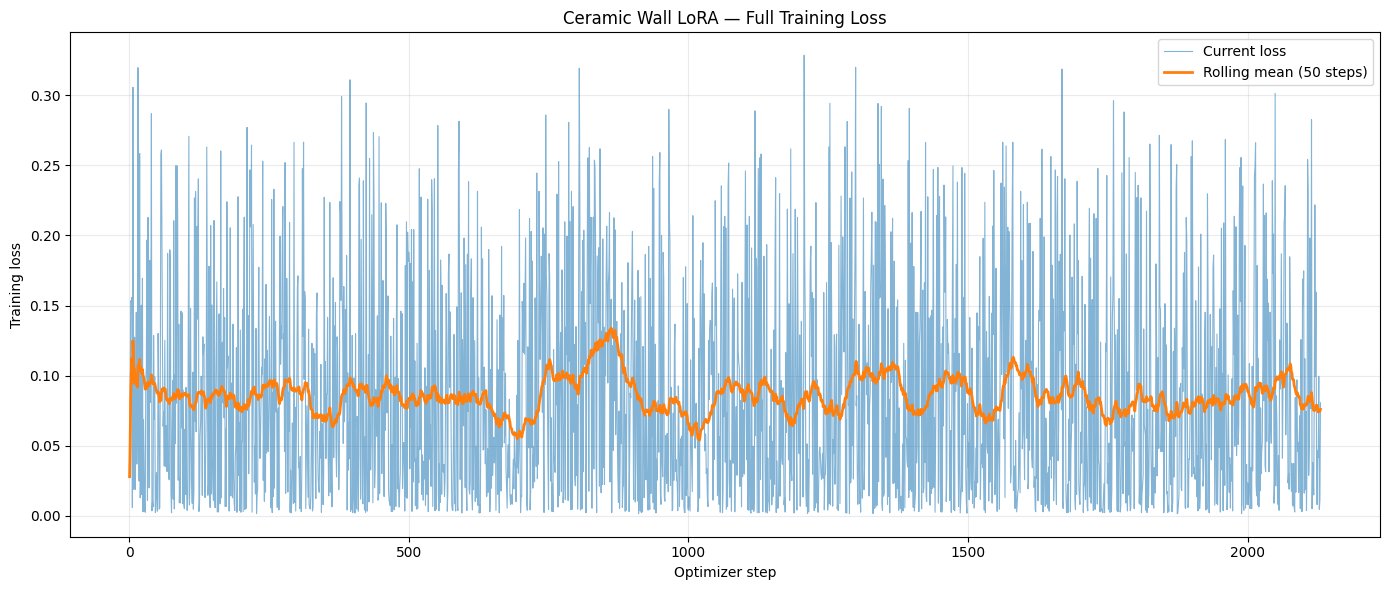

,Metric,Value
0,First current loss,0.027938
1,Final current loss,0.080695
2,Minimum rolling loss,0.027938
3,Final rolling loss,0.075982
4,Logged steps,2130.000000
5,Maximum optimizer step,2130.000000


Saved: /kaggle/working/ceramic_wall_lora_project/previews/training_loss_corrected.png


In [15]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing.event_accumulator import (
    EventAccumulator
)

event_files = sorted(
    LOG_DIR.rglob("events.out.tfevents*")
)

assert event_files, (
    f"لم يتم العثور على TensorBoard events داخل: {LOG_DIR}"
)

print("TensorBoard event files found:")
for event_file in event_files:
    print(" -", event_file)


event_candidates = []

for event_file in event_files:
    try:
        accumulator = EventAccumulator(
            str(event_file),
            size_guidance={"scalars": 0},
        )
        accumulator.Reload()

        scalar_tags = accumulator.Tags().get(
            "scalars",
            [],
        )

        # نستخدم Current Loss بشكل صريح
        if "loss/current" not in scalar_tags:
            continue

        events = accumulator.Scalars(
            "loss/current"
        )

        if not events:
            continue

        frame = pd.DataFrame({
            "step": [
                int(event.step)
                for event in events
            ],
            "loss": [
                float(event.value)
                for event in events
            ],
        })

        event_candidates.append({
            "event_file": event_file,
            "frame": frame,
            "event_count": len(frame),
            "max_step": int(frame["step"].max()),
        })

    except Exception as error:
        print(
            "Skipped:",
            event_file,
            repr(error),
        )


assert event_candidates, (
    "لم أجد loss/current داخل TensorBoard events."
)

selected = max(
    event_candidates,
    key=lambda item: (
        item["event_count"],
        item["max_step"],
    ),
)

loss_df = selected["frame"].copy()

loss_df = (
    loss_df
    .sort_values("step")
    .drop_duplicates(
        subset="step",
        keep="last",
    )
    .reset_index(drop=True)
)

loss_df = loss_df[
    loss_df["step"] >= 0
].copy()

ROLLING_WINDOW = 50

loss_df["rolling_loss"] = (
    loss_df["loss"]
    .rolling(
        window=ROLLING_WINDOW,
        min_periods=1,
    )
    .mean()
)

print()
print("Selected full-training event:")
print(selected["event_file"])
print("Logged points:", len(loss_df))
print("Maximum step:", loss_df["step"].max())

assert len(loss_df) >= 2000, (
    f"عدد الخطوات المقروء منخفض: {len(loss_df)}"
)



plt.figure(figsize=(14, 6))

plt.plot(
    loss_df["step"],
    loss_df["loss"],
    linewidth=0.8,
    alpha=0.55,
    label="Current loss",
)

plt.plot(
    loss_df["step"],
    loss_df["rolling_loss"],
    linewidth=2,
    label=f"Rolling mean ({ROLLING_WINDOW} steps)",
)

plt.xlabel("Optimizer step")
plt.ylabel("Training loss")
plt.title("Ceramic Wall LoRA — Full Training Loss")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

LOSS_PLOT_PATH = (
    PREVIEW_DIR /
    "training_loss_corrected.png"
)

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


summary_df = pd.DataFrame([
    {
        "Metric": "First current loss",
        "Value": round(
            float(loss_df.iloc[0]["loss"]),
            6,
        ),
    },
    {
        "Metric": "Final current loss",
        "Value": round(
            float(loss_df.iloc[-1]["loss"]),
            6,
        ),
    },
    {
        "Metric": "Minimum rolling loss",
        "Value": round(
            float(loss_df["rolling_loss"].min()),
            6,
        ),
    },
    {
        "Metric": "Final rolling loss",
        "Value": round(
            float(loss_df.iloc[-1]["rolling_loss"]),
            6,
        ),
    },
    {
        "Metric": "Logged steps",
        "Value": int(len(loss_df)),
    },
    {
        "Metric": "Maximum optimizer step",
        "Value": int(loss_df["step"].max()),
    },
])

display(summary_df)

loss_df.to_csv(
    WORK_ROOT / "training_loss_corrected.csv",
    index=False,
)

print("Saved:", LOSS_PLOT_PATH)

In [16]:

cleanup_memory()

from diffusers import (
    StableDiffusionPipeline,
    EulerAncestralDiscreteScheduler,
)

def load_evaluation_pipeline():
    common_kwargs = dict(
        torch_dtype=torch.float16,
        safety_checker=None,
        requires_safety_checker=False,
    )

    if isinstance(BASE_MODEL, Path) and BASE_MODEL.is_file():
        pipeline = StableDiffusionPipeline.from_single_file(
            str(BASE_MODEL),
            **common_kwargs,
        )
    else:
        pipeline = StableDiffusionPipeline.from_pretrained(
            str(BASE_MODEL),
            **common_kwargs,
        )

    pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(
        pipeline.scheduler.config
    )
    pipeline.enable_attention_slicing()
    pipeline.enable_vae_slicing()
    pipeline.enable_vae_tiling()

    pipeline.enable_model_cpu_offload(gpu_id=0)
    return pipeline

pipe = load_evaluation_pipeline()

FINAL_LORA = OUTPUT_DIR / "ceramic_wall_lora.safetensors"
if not FINAL_LORA.exists():
    epoch_files = sorted(OUTPUT_DIR.glob("ceramic_wall_lora-*.safetensors"))
    assert epoch_files, "لم أجد LoRA نهائية أو Checkpoint."
    FINAL_LORA = epoch_files[-1]

print("Evaluation LoRA:", FINAL_LORA)


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluation LoRA: /kaggle/working/ceramic_wall_lora_project/output/ceramic_wall_lora.safetensors


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

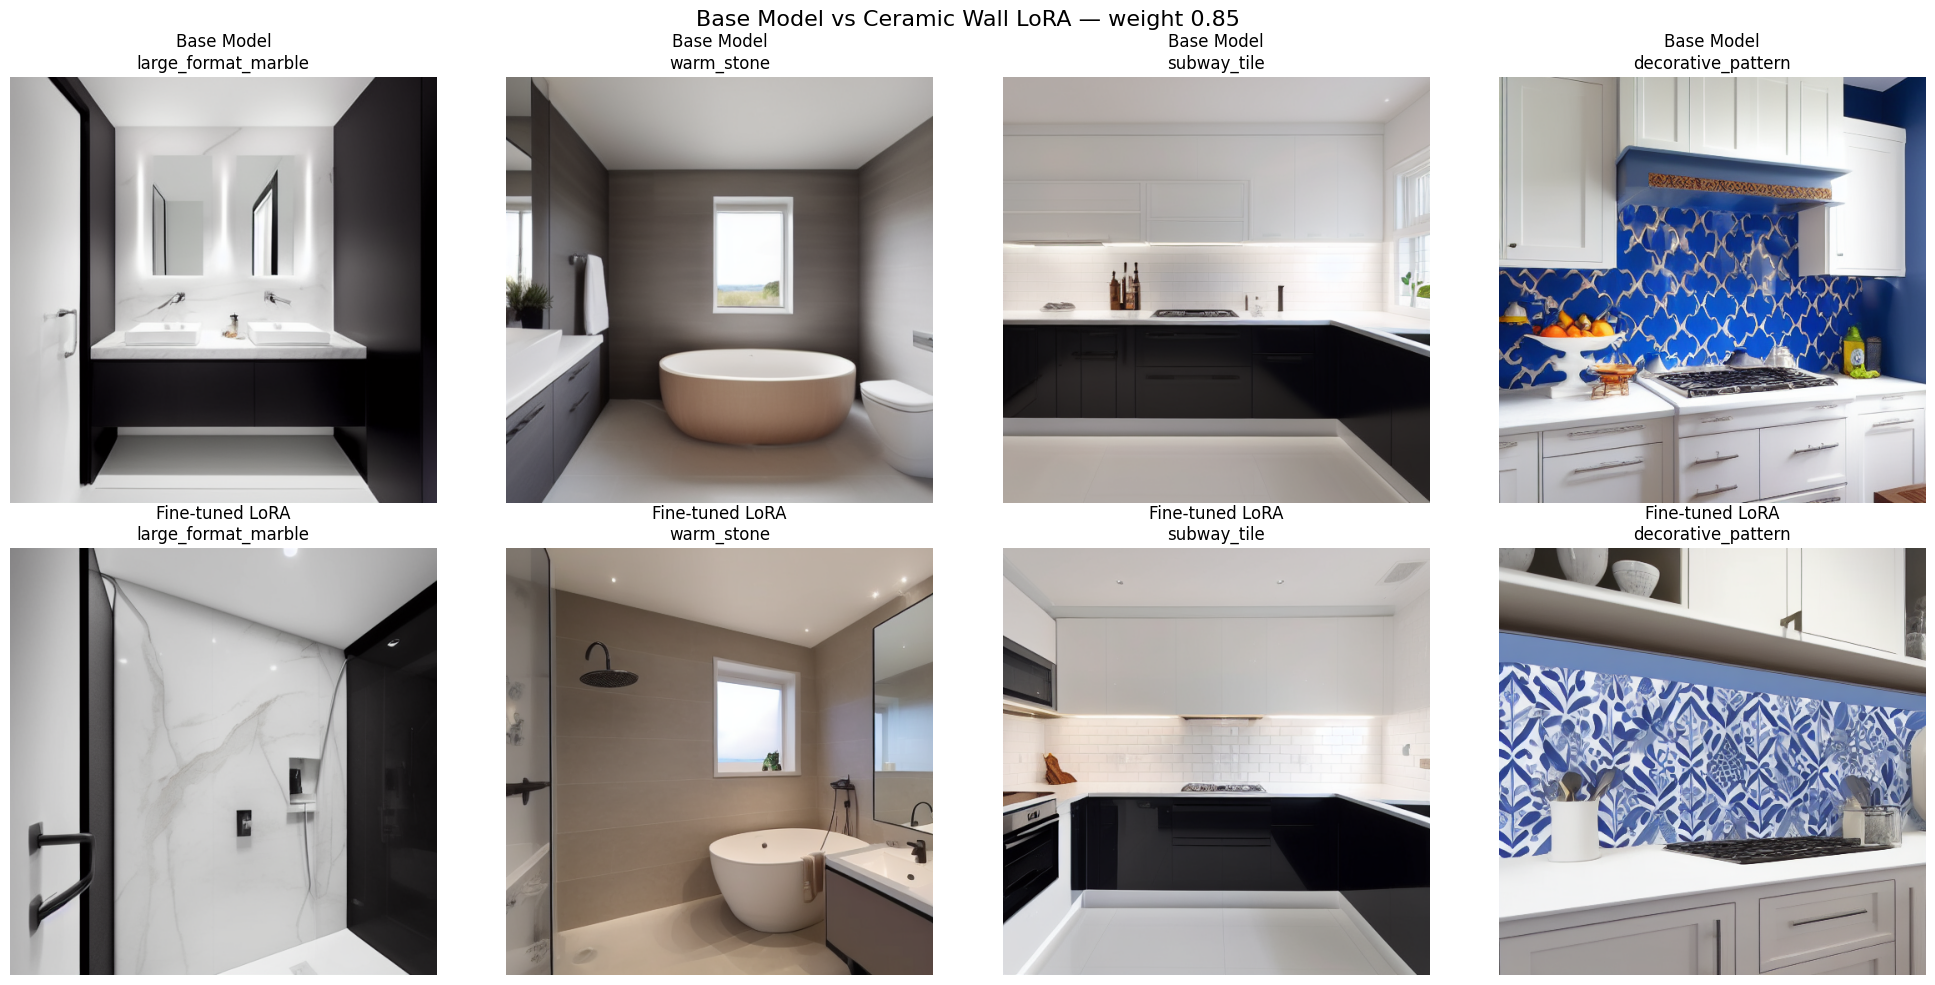

,prompt_name,seed,base_image,lora_image,lora_weight
0,large_format_marble,42,/kaggle/working/ceramic_wall_lora_project/prev...,/kaggle/working/ceramic_wall_lora_project/prev...,0.85
1,warm_stone,43,/kaggle/working/ceramic_wall_lora_project/prev...,/kaggle/working/ceramic_wall_lora_project/prev...,0.85
2,subway_tile,44,/kaggle/working/ceramic_wall_lora_project/prev...,/kaggle/working/ceramic_wall_lora_project/prev...,0.85
3,decorative_pattern,45,/kaggle/working/ceramic_wall_lora_project/prev...,/kaggle/working/ceramic_wall_lora_project/prev...,0.85


Saved visual comparison: /kaggle/working/ceramic_wall_lora_project/previews/evaluation/base_vs_final_lora.png


In [17]:
EVAL_PROMPTS = [
    (
        "large_format_marble",
        "cerwall, photorealistic modern bathroom interior, full-height feature wall "
        "covered with large-format rectangular white marble-look ceramic wall tiles, "
        "straight grid layout, minimal white grout lines, polished finish, realistic scale"
    ),
    (
        "warm_stone",
        "cerwall, photorealistic elegant bathroom, wall covered with large-format "
        "warm greige stone-look ceramic tiles, straight grid layout, thin beige grout lines, "
        "matte mineral finish, correct wall perspective"
    ),
    (
        "subway_tile",
        "cerwall, photorealistic kitchen interior, backsplash covered with glossy white "
        "rectangular ceramic subway tiles, horizontal running-bond layout, thin light grout, "
        "realistic reflections and tile scale"
    ),
    (
        "decorative_pattern",
        "cerwall, photorealistic kitchen backsplash, decorative patterned ceramic wall tiles, "
        "blue and white geometric motifs, regular repeating layout, matte finish, "
        "sharp grout joints and realistic perspective"
    ),
]

NEGATIVE_PROMPT = (
    "floor tiles, tiled floor, ceramic on floor, ceramic on ceiling, tiles on furniture, "
    "wallpaper, carpet, rug, deformed room, warped wall, distorted tile grid, "
    "broken grout lines, melted texture, blurry, low resolution, artifacts, text, logo, watermark"
)

def generate_prompt_set(pipeline, prompts, output_prefix):
    generated = []
    for index, (prompt_name, prompt) in enumerate(prompts):
        seed = SEED + index
        generator = torch.Generator(device="cuda").manual_seed(seed)

        image = pipeline(
            prompt=prompt,
            negative_prompt=NEGATIVE_PROMPT,
            num_inference_steps=30,
            guidance_scale=7.0,
            width=512,
            height=512,
            generator=generator,
        ).images[0]

        output_path = EVAL_DIR / f"{output_prefix}__{prompt_name}.png"
        image.save(output_path)
        generated.append({
            "prompt_name": prompt_name,
            "prompt": prompt,
            "seed": seed,
            "image": image,
            "path": str(output_path),
        })
    return generated

BASE_EVAL_PROMPTS = [
    (
        prompt_name,
        re.sub(
            rf"^{re.escape(TRIGGER_TOKEN)}\s*,\s*",
            "",
            prompt,
            flags=re.IGNORECASE,
        ),
    )
    for prompt_name, prompt in EVAL_PROMPTS
]

base_results = generate_prompt_set(
    pipe,
    BASE_EVAL_PROMPTS,
    "base_model",
)

adapter_name = "ceramic_wall_final"
pipe.load_lora_weights(
    str(FINAL_LORA.parent),
    weight_name=FINAL_LORA.name,
    adapter_name=adapter_name,
)
pipe.set_adapters(
    [adapter_name],
    adapter_weights=[LORA_TEST_WEIGHT],
)

lora_results = generate_prompt_set(
    pipe,
    EVAL_PROMPTS,
    "final_lora",
)

fig, axes = plt.subplots(
    2,
    len(EVAL_PROMPTS),
    figsize=(5 * len(EVAL_PROMPTS), 10),
)

for column, result in enumerate(base_results):
    axes[0, column].imshow(result["image"])
    axes[0, column].set_title(f"Base Model\n{result['prompt_name']}")
    axes[0, column].axis("off")

for column, result in enumerate(lora_results):
    axes[1, column].imshow(result["image"])
    axes[1, column].set_title(f"Fine-tuned LoRA\n{result['prompt_name']}")
    axes[1, column].axis("off")

plt.suptitle(
    f"Base Model vs Ceramic Wall LoRA — weight {LORA_TEST_WEIGHT}",
    fontsize=16,
)
plt.tight_layout()

comparison_path = EVAL_DIR / "base_vs_final_lora.png"
plt.savefig(comparison_path, dpi=180, bbox_inches="tight")
plt.show()

comparison_records = []
for base_item, lora_item in zip(base_results, lora_results):
    comparison_records.append({
        "prompt_name": base_item["prompt_name"],
        "seed": base_item["seed"],
        "base_image": base_item["path"],
        "lora_image": lora_item["path"],
        "lora_weight": LORA_TEST_WEIGHT,
    })

comparison_df = pd.DataFrame(comparison_records)
comparison_df.to_csv(EVAL_DIR / "base_vs_lora.csv", index=False)
display(comparison_df)

try:
    pipe.delete_adapters(adapter_name)
except Exception:
    pipe.unload_lora_weights()

cleanup_memory()
print("Saved visual comparison:", comparison_path)
